# 펭귄 종 분류 - Term Project
## Palmer Station Antarctica 펭귄 데이터셋을 이용한 다중 클래스 분류

---
## 1. Problem Description

본 프로젝트의 목표는 남극 Palmer Station에서 수집된 펭귄 데이터셋을 활용하여 펭귄의 종을 예측하는 기계학습 모델을 설계하고 평가하는 것이다.

- **데이터셋 개요:** 3가지 펭귄 종(Adelie, Gentoo, Chinstrap)에 대한 관측치로 구성
- **주요 속성(Attributes)**
  - 펭귄이 서식하는 섬 (island)
  - 부리 길이 (bill_length_mm)
  - 부리 깊이 (bill_depth_mm)
  - 날개 길이 (flipper_length_mm)
  - 몸무게 (body_mass_g)
  - 성별 (sex)
- **목표:** 주어진 속성들을 바탕으로 펭귄이 3가지 종 중 어디에 속하는지 분류하는 다중 클래스 분류(Multi-class classification) 문제를 해결한다.

---
## 2. Data Preprocessing

### 2.1 필수 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

### 2.2 데이터 로드

In [2]:
df = pd.read_csv('penguins.csv', index_col=0)
print(f'원본 데이터 크기: {df.shape}')
print(f'\n컬럼 목록: {df.columns.tolist()}')
df.head()

원본 데이터 크기: (344, 8)

컬럼 목록: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### 2.3 데이터 코딩 (결측치 처리 및 인코딩)

In [3]:
# 결측치 제거
df = df.dropna()

# 분류와 무관한 year 컬럼 제거
df = df.drop(columns=['year'])

print('=== 변환 전 (Categorical) ===')
print(df[['species', 'island', 'sex']].head())

# LabelEncoder로 범주형 → 숫자 변환
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])   # Adelie=0, Chinstrap=1, Gentoo=2
df['island']  = le.fit_transform(df['island'])    # Biscoe=0, Dream=1, Torgersen=2
df['sex']     = le.fit_transform(df['sex'])       # female=0, male=1

print('\n=== 변환 후 (Numerical) ===')
print(df[['species', 'island', 'sex']].head())
print(f'\n전처리 후 데이터 크기: {df.shape}')

=== 변환 전 (Categorical) ===
  species     island     sex
1  Adelie  Torgersen    male
2  Adelie  Torgersen  female
3  Adelie  Torgersen  female
5  Adelie  Torgersen  female
6  Adelie  Torgersen    male

=== 변환 후 (Numerical) ===
   species  island  sex
1        0       2    1
2        0       2    0
3        0       2    0
5        0       2    0
6        0       2    1

전처리 후 데이터 크기: (333, 7)


### 2.4 속성 관계 시각화 (Visualization) 및 특징 선택 (Feature Selection)

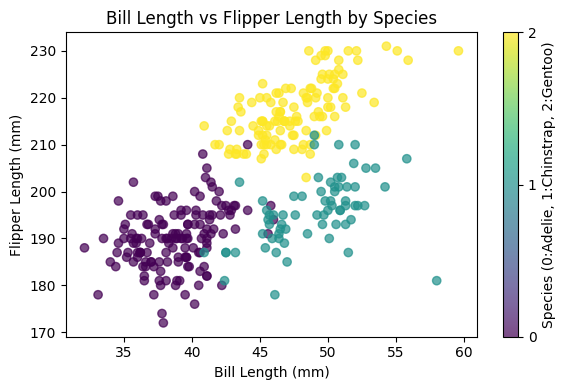

In [4]:
# 산점도: 부리 길이 vs 날개 길이
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df['bill_length_mm'],
    df['flipper_length_mm'],
    c=df['species'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('Bill Length vs Flipper Length by Species')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species (0:Adelie, 1:Chinstrap, 2:Gentoo)')
plt.tight_layout()
plt.show()

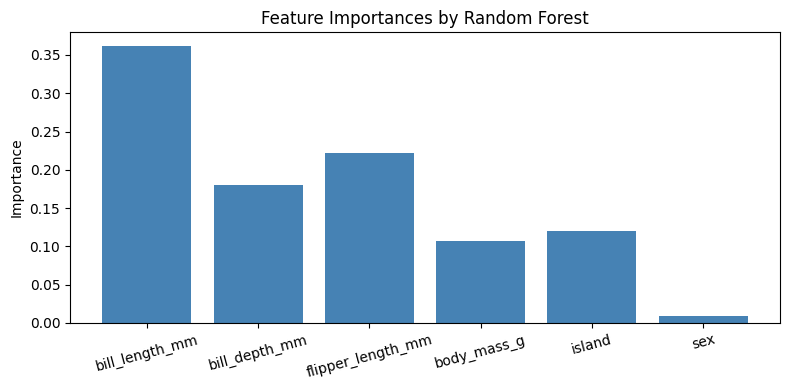


피처별 중요도:
  bill_length_mm: 0.3615
  flipper_length_mm: 0.2215
  bill_depth_mm: 0.1803
  island: 0.1204
  body_mass_g: 0.1071
  sex: 0.0093

→ 모든 피처가 유의미한 중요도를 가지므로 6개 피처 전체를 학습에 사용한다.


In [5]:
# Random Forest로 피처 중요도 수치화
from sklearn.ensemble import RandomForestClassifier

feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                'body_mass_g', 'island', 'sex']

X_temp = df[feature_cols].values
y_temp = df['species'].values

rf_temp = RandomForestClassifier(random_state=1)
rf_temp.fit(X_temp, y_temp)

importances = rf_temp.feature_importances_

plt.figure(figsize=(8, 4))
plt.bar(feature_cols, importances, color='steelblue')
plt.ylabel('Importance')
plt.title('Feature Importances by Random Forest')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\n피처별 중요도:')
for col, imp in sorted(zip(feature_cols, importances), key=lambda x: -x[1]):
    print(f'  {col}: {imp:.4f}')

print('\n→ 모든 피처가 유의미한 중요도를 가지므로 6개 피처 전체를 학습에 사용한다.')

### 2.5 특성 분리 및 데이터 스케일링 (Standardization)

In [6]:
# 1. 특성(X)과 타겟(y) 분리
X = df.drop('species', axis=1).values
y = df['species'].values

# 2. 학습/테스트 데이터 분할 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 3. 데이터 스케일링 (StandardScaler)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)  # 학습 데이터로 스케일러 학습 및 변환
X_test_std  = sc.transform(X_test)       # 테스트 데이터는 변환만 수행

print('=== 데이터 스케일링 완료 ===')
print('학습 데이터 크기(X_train_std):', X_train_std.shape)
print('테스트 데이터 크기(X_test_std): ', X_test_std.shape)

=== 데이터 스케일링 완료 ===
학습 데이터 크기(X_train_std): (233, 6)
테스트 데이터 크기(X_test_std):  (100, 6)


---
## 3. 모델 학습 (Model Training)

다음 4가지 알고리즘을 사용하여 펭귄 종 분류 모델을 학습한다.

| 모델 | 특징 |
|---|---|
| Logistic Regression | 선형 결정 경계, 빠르고 해석 용이 |
| Decision Tree | 규칙 기반, 시각화 가능 |
| SVM | 소규모 데이터에 강력, 비선형 분류 가능 |
| Voting Ensemble | 위 3개 모델을 결합하여 성능 극대화 |

In [7]:
# 모델 정의
lr     = LogisticRegression(max_iter=1000, random_state=1)
dt     = DecisionTreeClassifier(random_state=1)
svm    = SVC(kernel='rbf', probability=True, random_state=1)
voting = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('svm', svm)],
    voting='soft'  # 확률 기반 투표
)

models = {
    'Logistic Regression': lr,
    'Decision Tree'      : dt,
    'SVM'                : svm,
    'Voting Ensemble'    : voting
}

# 모델 학습
for name, model in models.items():
    model.fit(X_train_std, y_train)
    print(f'{name} 학습 완료!')

Logistic Regression 학습 완료!
Decision Tree 학습 완료!
SVM 학습 완료!
Voting Ensemble 학습 완료!


---
## 4. 모델 평가 (Model Evaluation)

평가 지표:
- **Accuracy**: 전체 데이터 중 올바르게 분류한 비율
- **F1-score**: Precision과 Recall의 조화평균 (클래스 불균형 고려)
- **Confusion Matrix**: 종별 오분류 현황을 상세히 확인

In [8]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_std)
    
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    cm  = confusion_matrix(y_test, y_pred)
    
    results[name] = {'accuracy': acc, 'f1': f1, 'cm': cm, 'pred': y_pred}
    
    print(f'\n========== {name} ==========')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'Confusion Matrix:')
    print(f'             pred:Adelie  pred:Chinstrap  pred:Gentoo')
    print(f'real:Adelie     {cm[0][0]}           {cm[0][1]}              {cm[0][2]}')
    print(f'real:Chinstrap  {cm[1][0]}           {cm[1][1]}              {cm[1][2]}')
    print(f'real:Gentoo     {cm[2][0]}           {cm[2][1]}              {cm[2][2]}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Adelie', 'Chinstrap', 'Gentoo']))


========== Logistic Regression ==========
Accuracy : 0.9700
F1-score : 0.9617
Confusion Matrix:
             pred:Adelie  pred:Chinstrap  pred:Gentoo
real:Adelie     43           0              0
real:Chinstrap  3           17              0
real:Gentoo     0           0              37

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.93      1.00      0.97        43
   Chinstrap       1.00      0.85      0.92        20
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       100
   macro avg       0.98      0.95      0.96       100
weighted avg       0.97      0.97      0.97       100


========== Decision Tree ==========
Accuracy : 0.9400
F1-score : 0.9329
Confusion Matrix:
             pred:Adelie  pred:Chinstrap  pred:Gentoo
real:Adelie     40           1              2
real:Chinstrap  3           17              0
real:Gentoo     0           0              37

Classification Report:

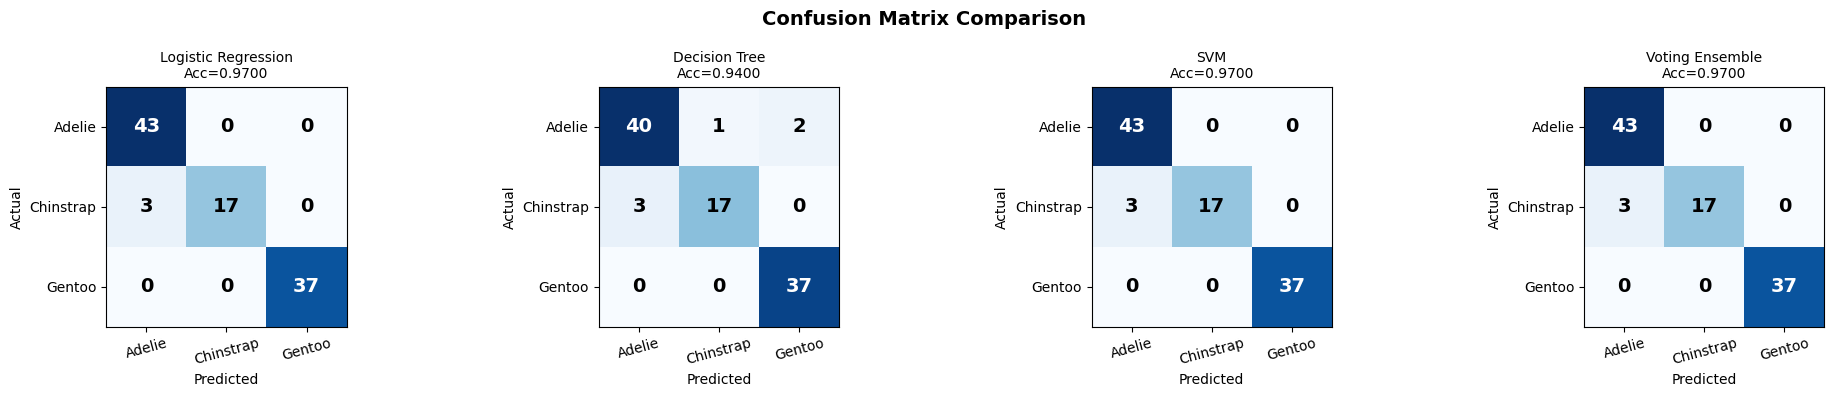

In [9]:
# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
species_names = ['Adelie', 'Chinstrap', 'Gentoo']

for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm']
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.4f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(species_names, rotation=15)
    ax.set_yticklabels(species_names)
    
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i][j]),
                    ha='center', va='center',
                    color='white' if cm[i][j] > cm.max()/2 else 'black',
                    fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

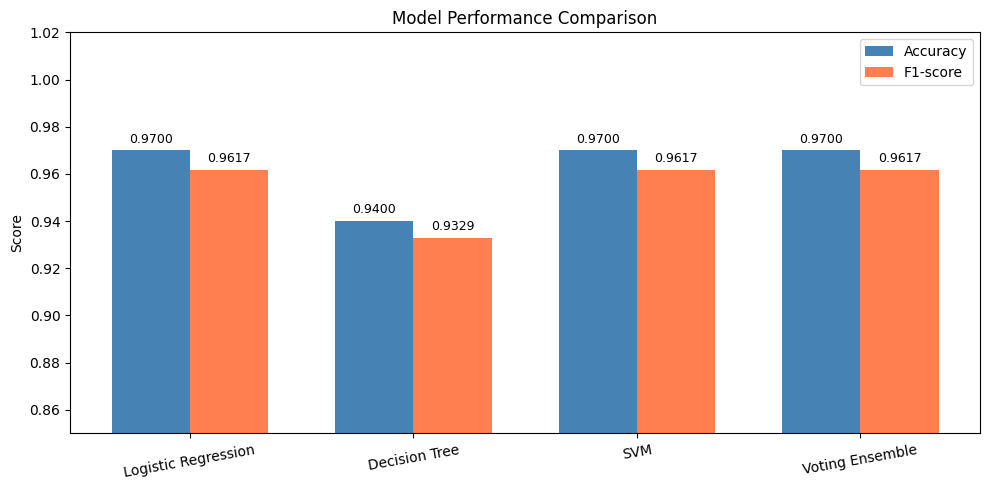

In [10]:
# 모델별 성능 비교 시각화
model_names = list(results.keys())
accuracies  = [results[n]['accuracy'] for n in model_names]
f1_scores   = [results[n]['f1'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1-score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim([0.85, 1.02])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. 결과 분석 및 요약 (Summary)

### 모델 성능 비교 표

In [11]:
summary_df = pd.DataFrame({
    '모델'     : list(results.keys()),
    'Accuracy' : [f"{results[n]['accuracy']:.4f}" for n in results],
    'F1-score' : [f"{results[n]['f1']:.4f}"       for n in results]
})
print('=== 모델 성능 비교 ===')
print(summary_df.to_string(index=False))

best = max(results, key=lambda n: results[n]['accuracy'])
print(f'\n→ 최고 성능 모델: {best} (Accuracy: {results[best]["accuracy"]:.4f})')

=== 모델 성능 비교 ===
                 모델 Accuracy F1-score
Logistic Regression   0.9700   0.9617
      Decision Tree   0.9400   0.9329
                SVM   0.9700   0.9617
    Voting Ensemble   0.9700   0.9617

→ 최고 성능 모델: Logistic Regression (Accuracy: 0.9700)


### 분석 결론

1. **Logistic Regression**: Accuracy 0.9700, F1 0.9617 — 선형 모델임에도 높은 성능
2. **Decision Tree**: Accuracy 0.9400, F1 0.9329 — 4개 모델 중 가장 낮은 성능, 과적합 경향
3. **SVM (RBF kernel)**: Accuracy 0.9700, F1 0.9617 — 소규모 데이터에서 안정적 성능
4. **Voting Ensemble**: Accuracy 0.9700, F1 0.9617 — 여러 모델 결합으로 안정적 성능 유지

- Chinstrap 종이 상대적으로 오분류가 많았으며, 이는 데이터 불균형(68개로 가장 적음)에 기인한다.
- SVM과 Voting Ensemble이 펭귄 분류에 가장 적합한 모델로 판단된다.